In [2]:
import pandas as pd
df = pd.read_parquet("normalised_run.parquet")

print(df.head())
print(df.shape)

                                               image  \
0  /data/test_images/2022_02_02 5nm Ag nanopartic...   
1  /data/test_images/2022_02_02 5nm Ag nanopartic...   
2  /data/test_images/2022_02_02 5nm Ag nanopartic...   
3  /data/test_images/2022_02_02 5nm Ag nanopartic...   
4  /data/test_images/2022_02_02 5nm Ag nanopartic...   

                                    clustered_labels  \
0  [6, 6, 6, 1, 1, 1, 1, 1, 7, 3, 7, 1, 7, 7, 6, ...   
1  [5, 4, 0, 0, 0, 0, 3, 3, 7, 4, 4, 6, 5, 4, 5, ...   
2  [4, 6, 2, 7, 2, 2, 5, 7, 1, 3, 1, 1, 7, 7, 4, ...   
3  [4, 4, 4, 5, 6, 6, 7, 1, 3, 7, 7, 6, 3, 5, 4, ...   
4  [5, 0, 4, 1, 1, 4, 6, 2, 3, 3, 2, 0, 4, 0, 5, ...   

                                           positions  \
0  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
1  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
2  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
3  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64], [...   
4  [[0, 0], [0, 16], [0, 32], [0, 48], [0, 64]

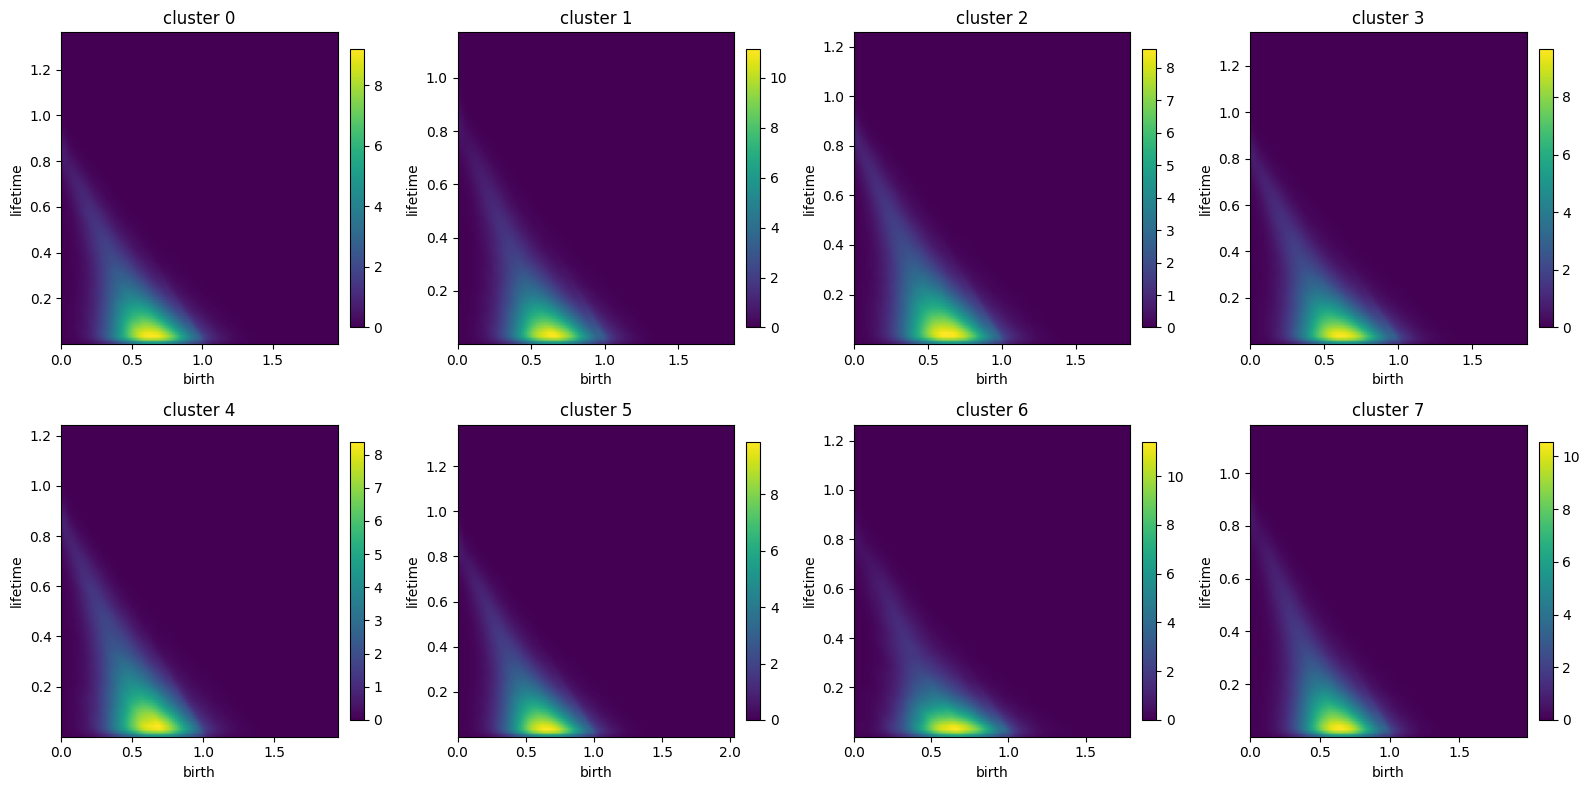

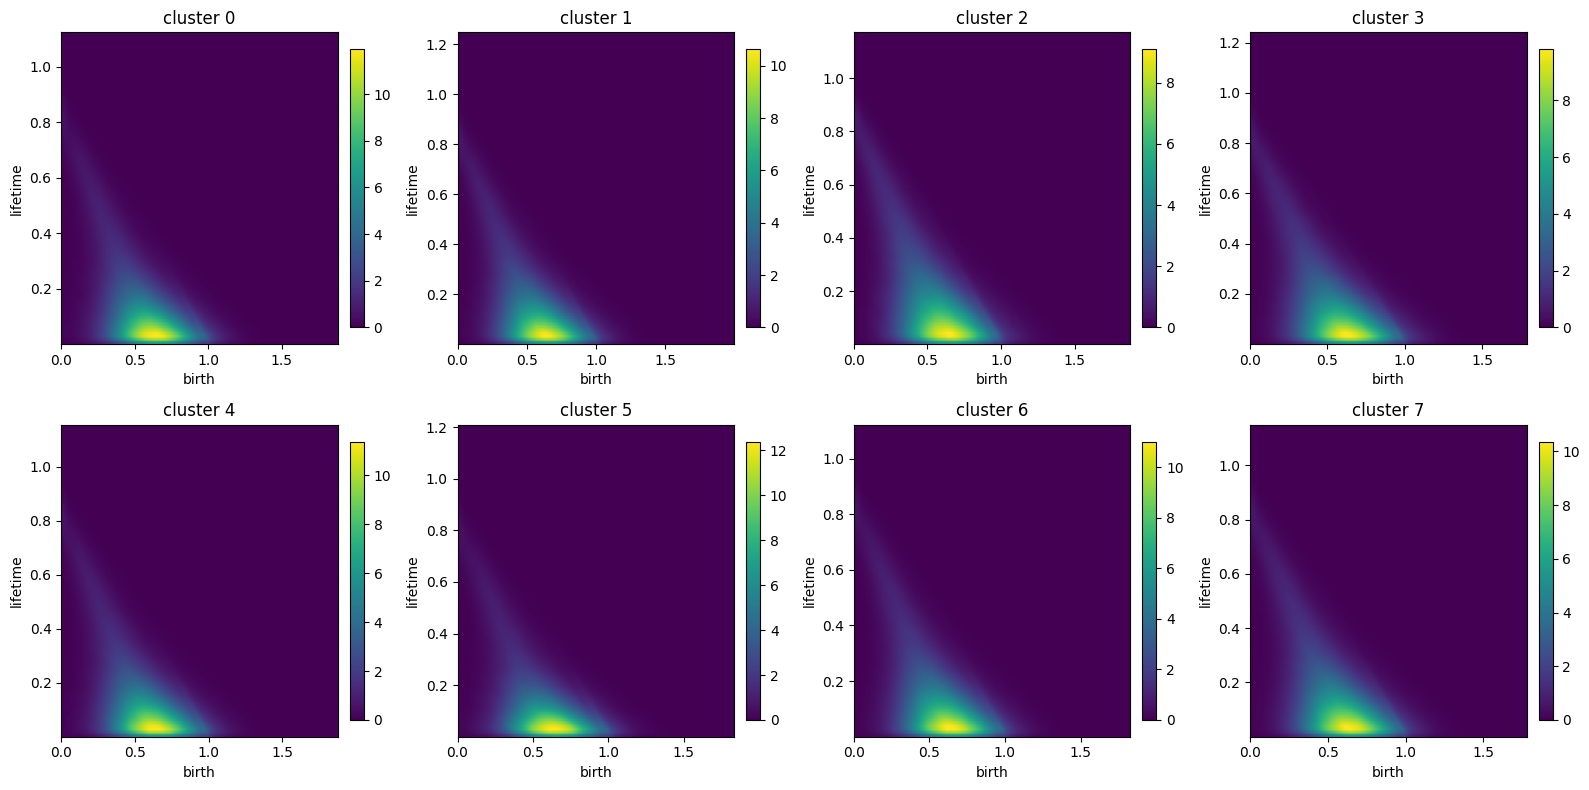

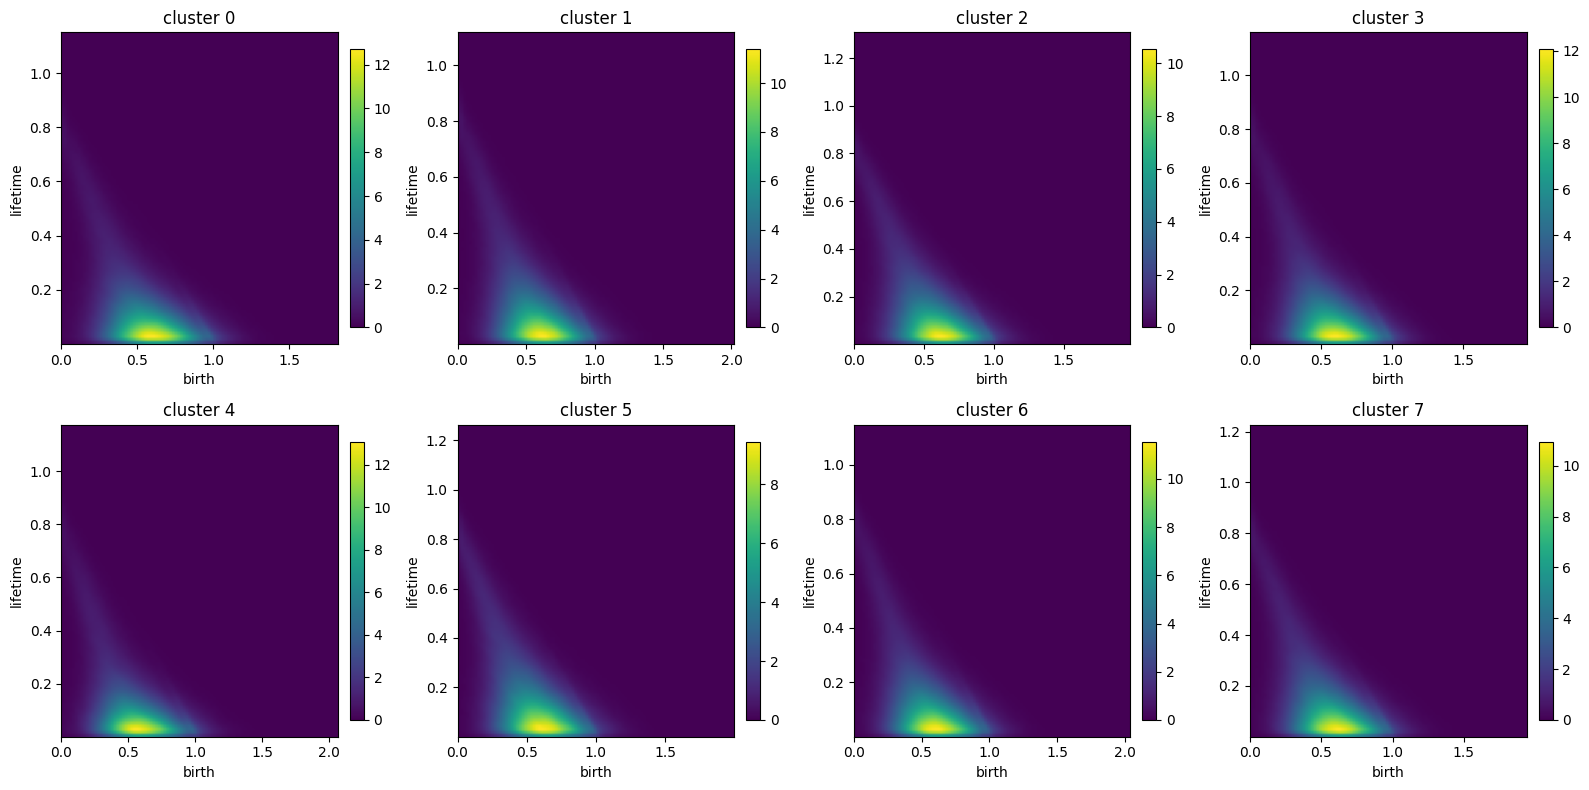

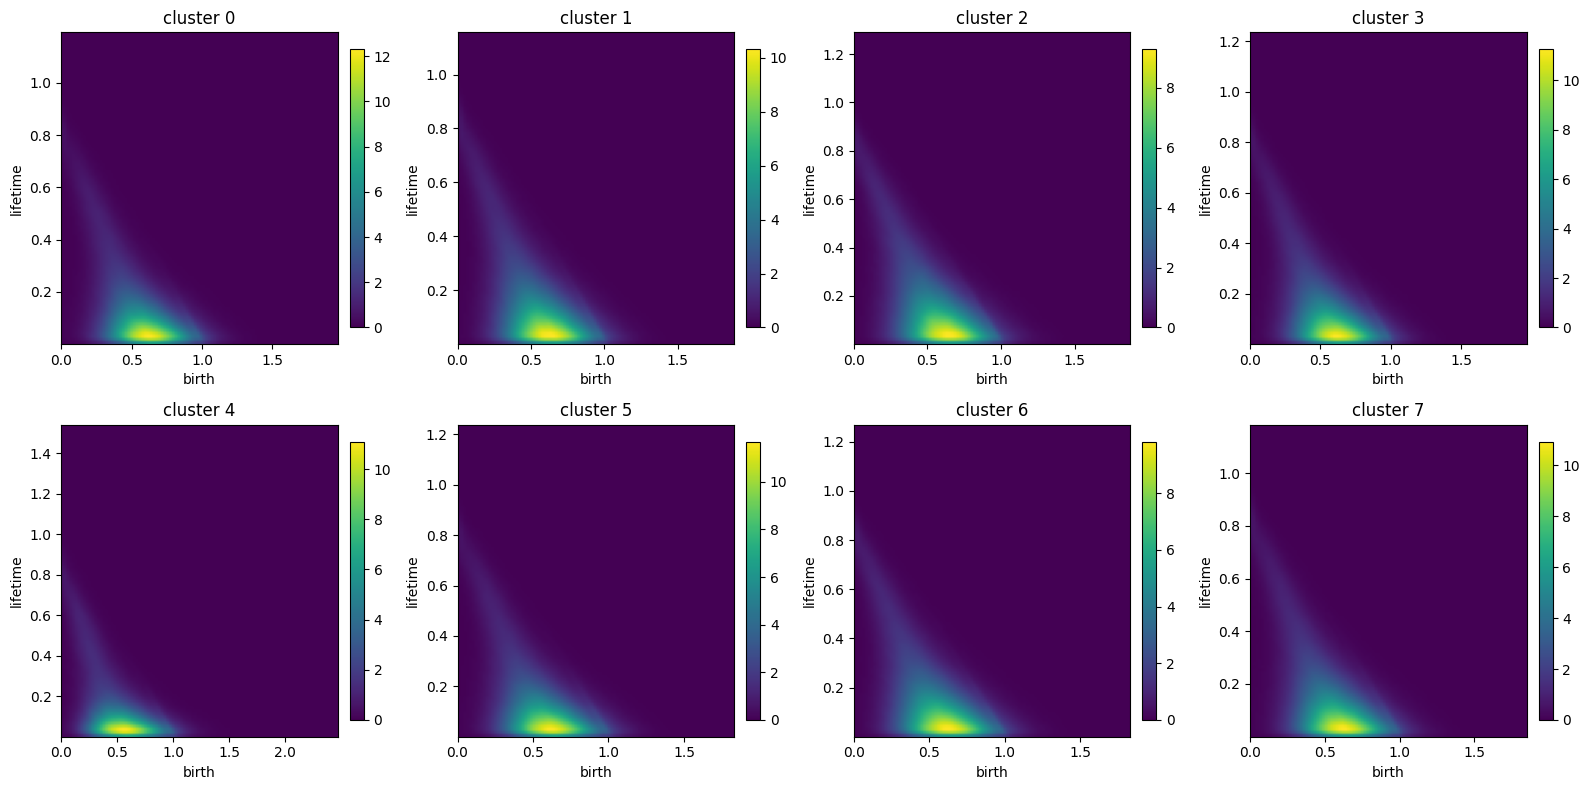

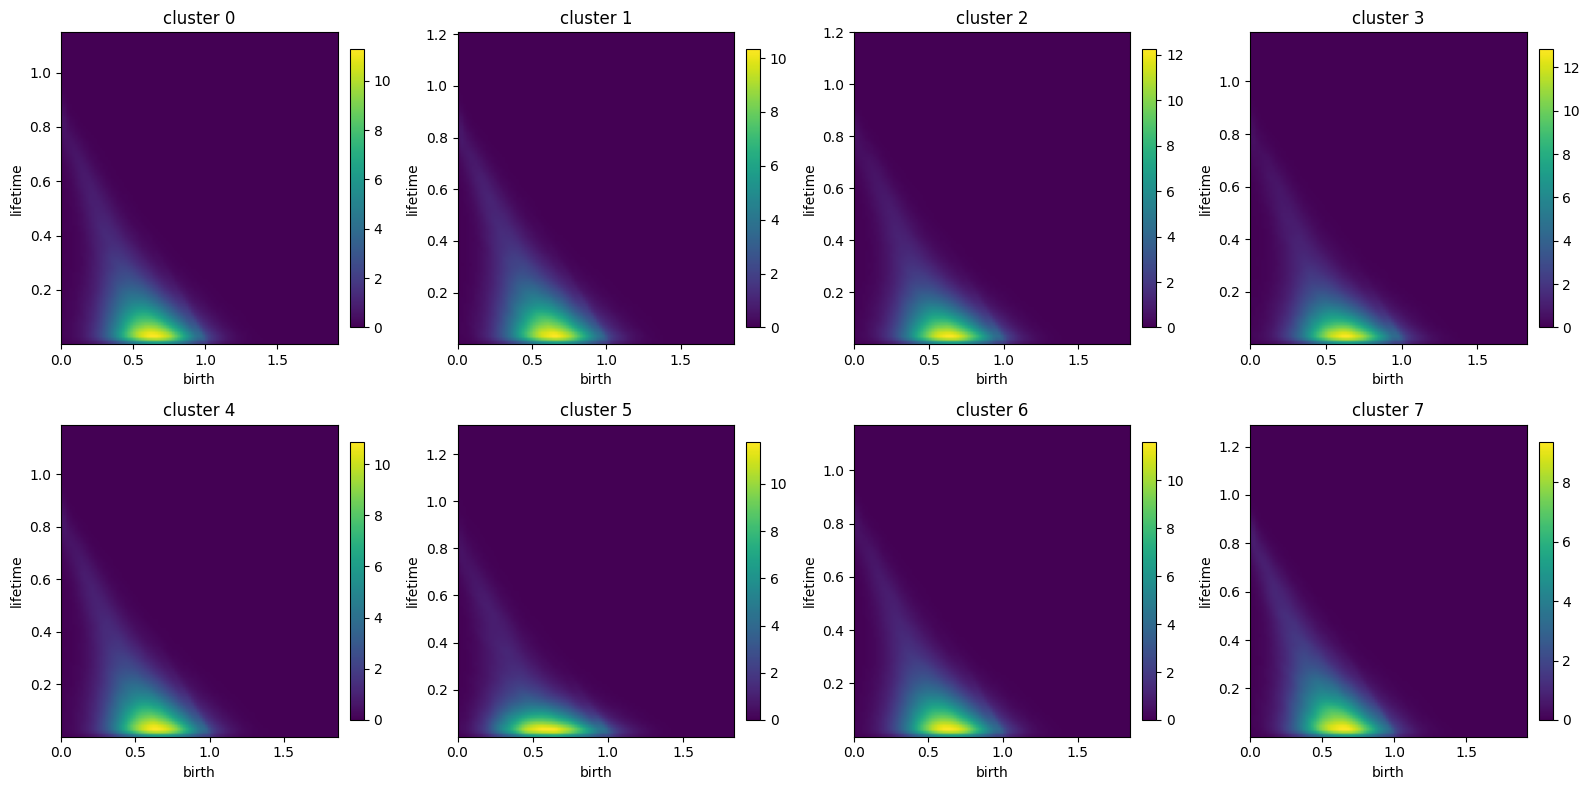

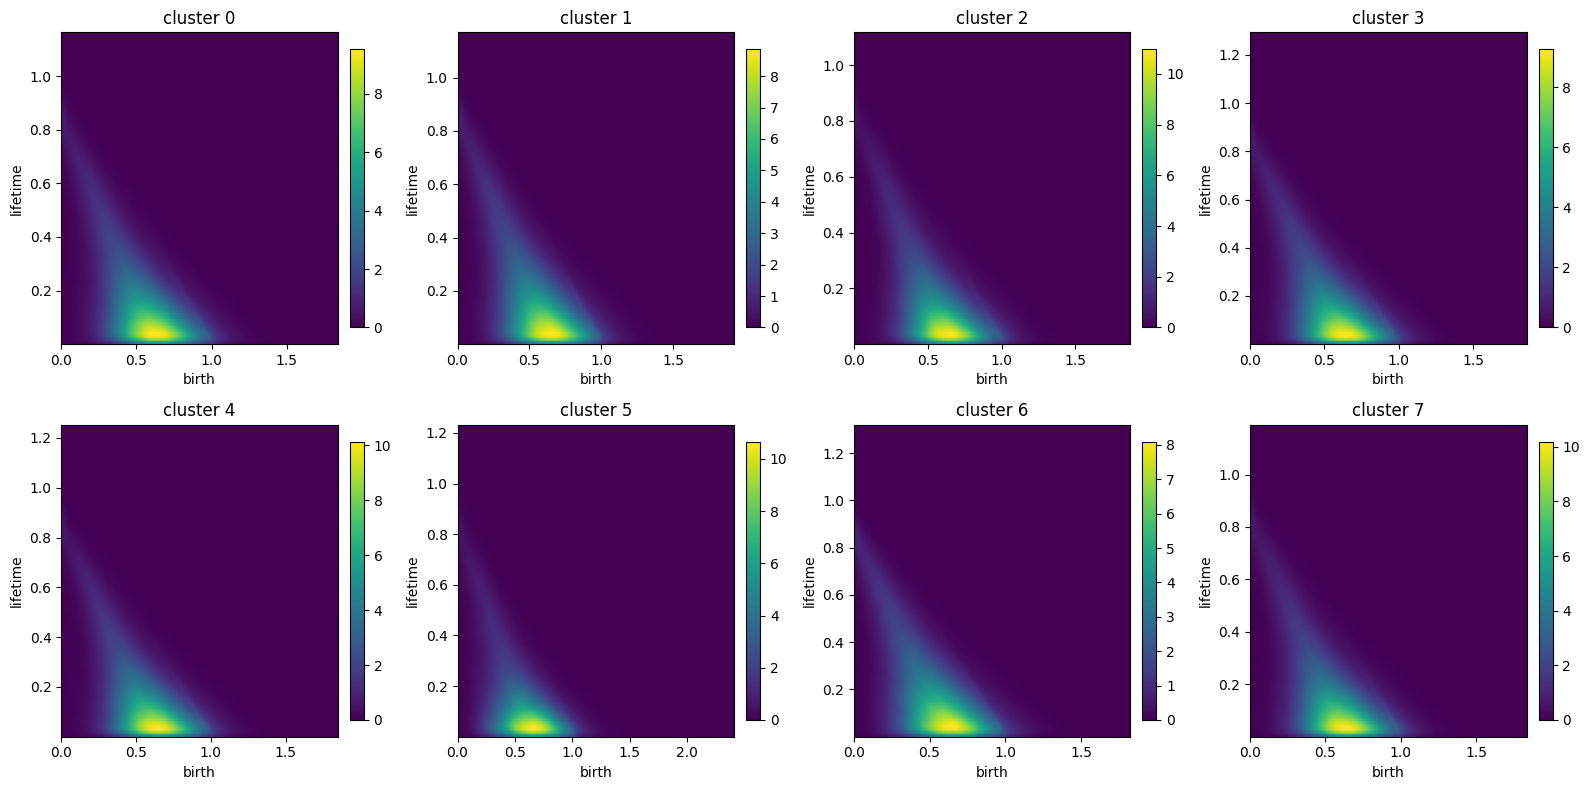

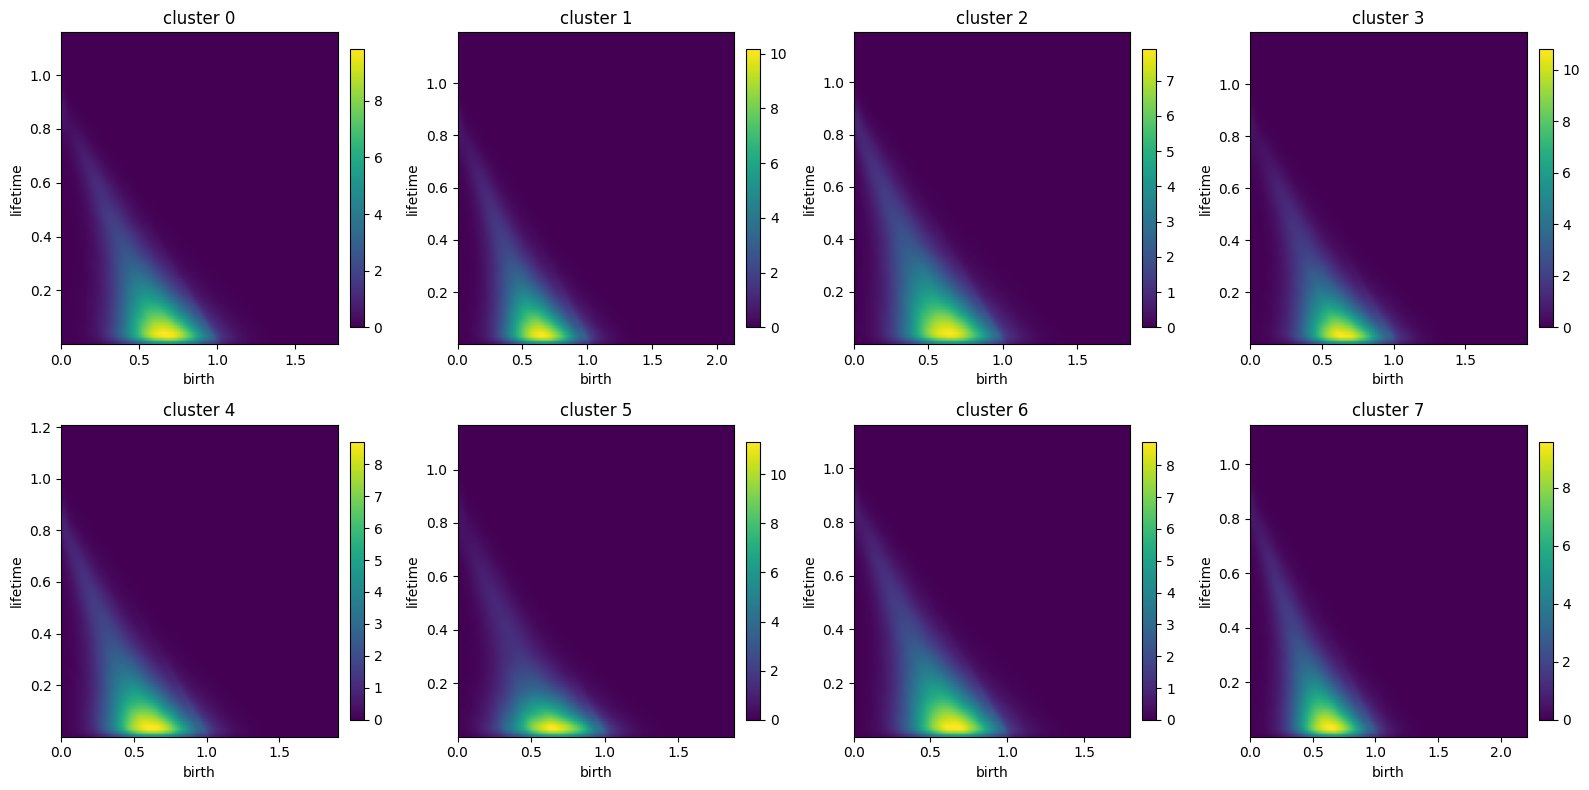

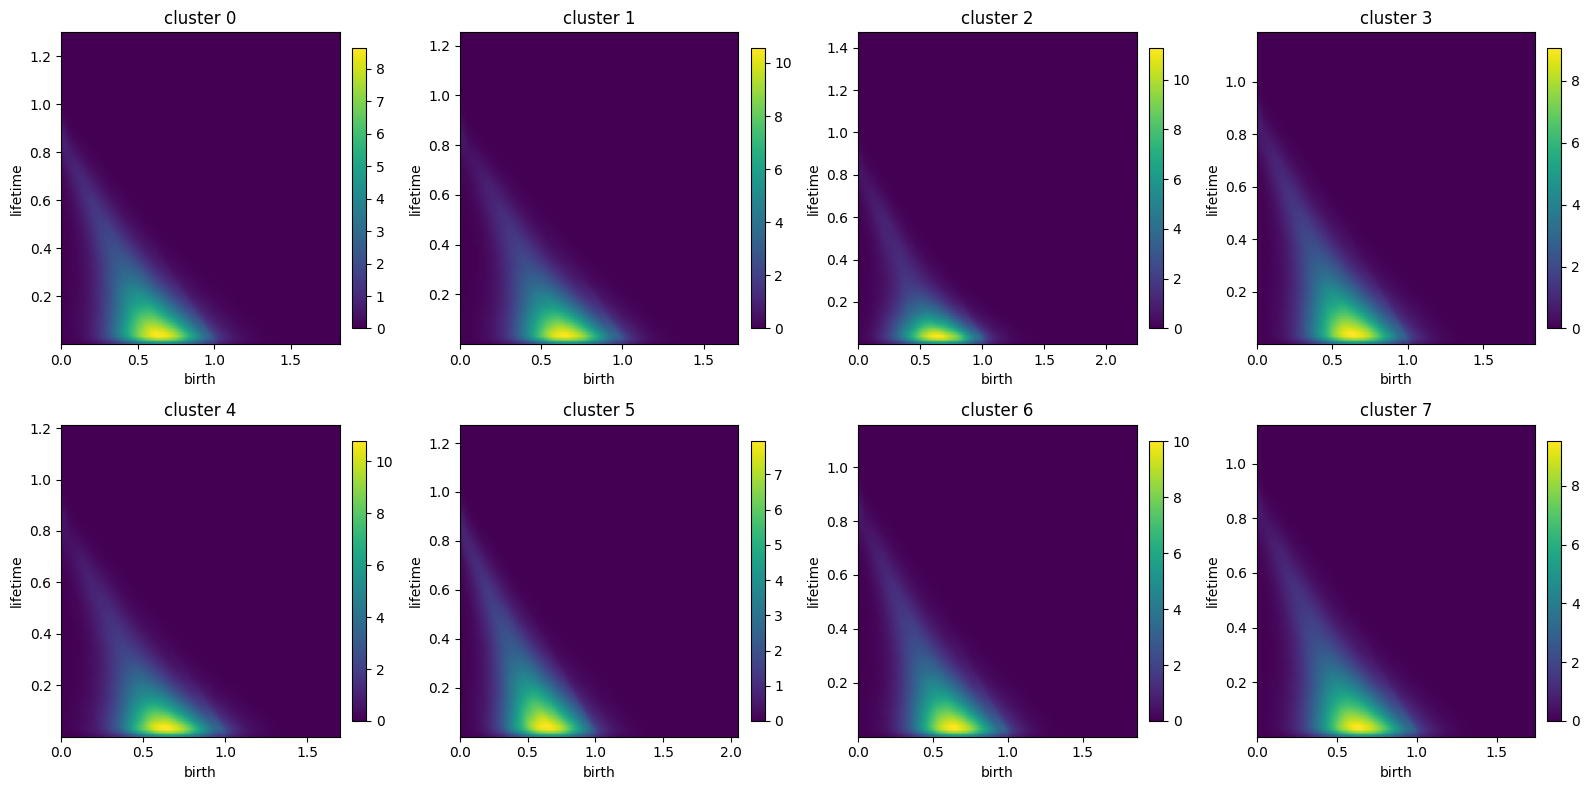

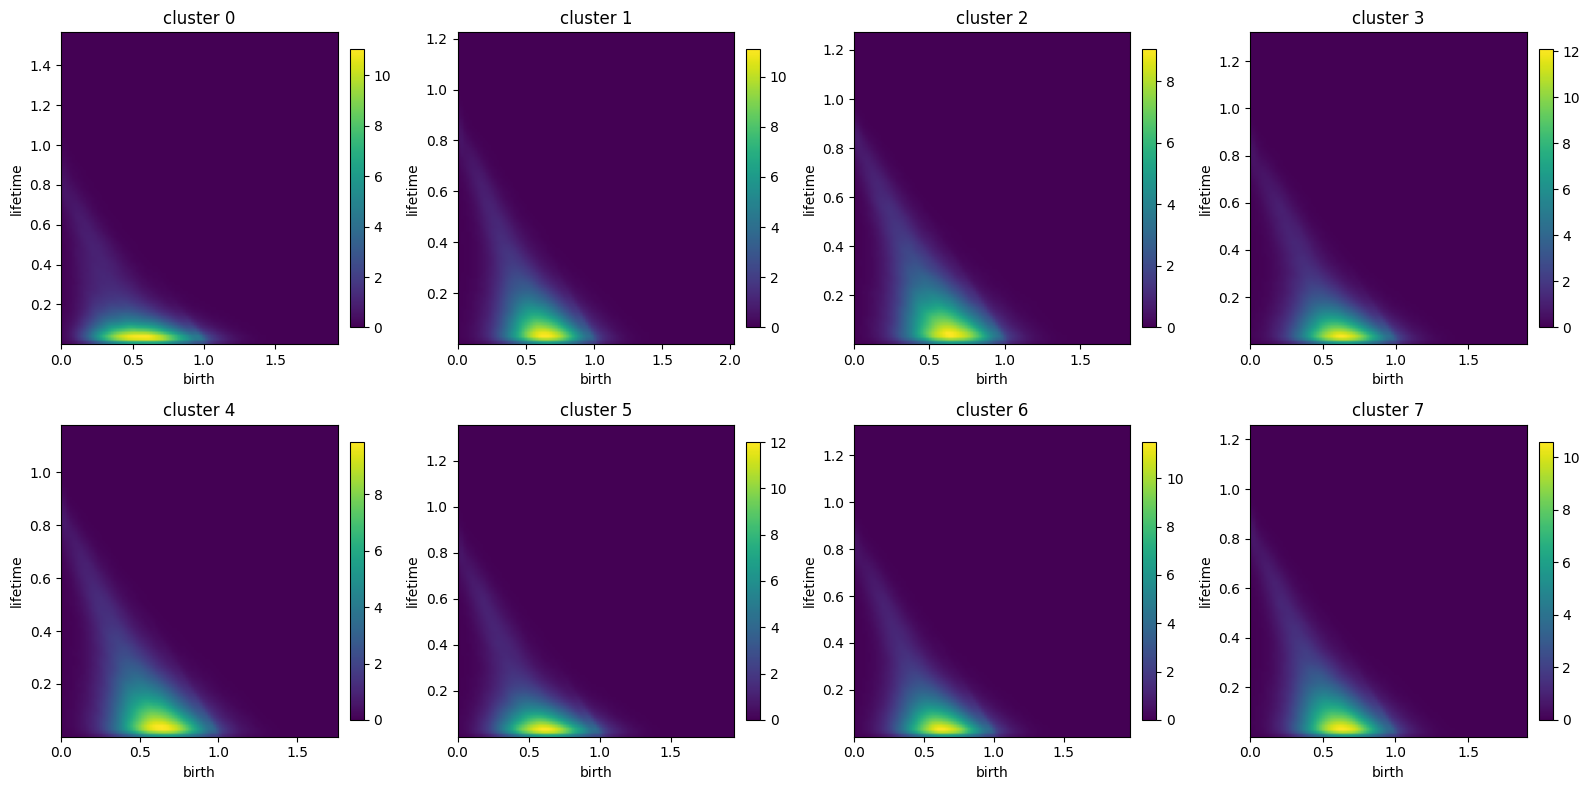

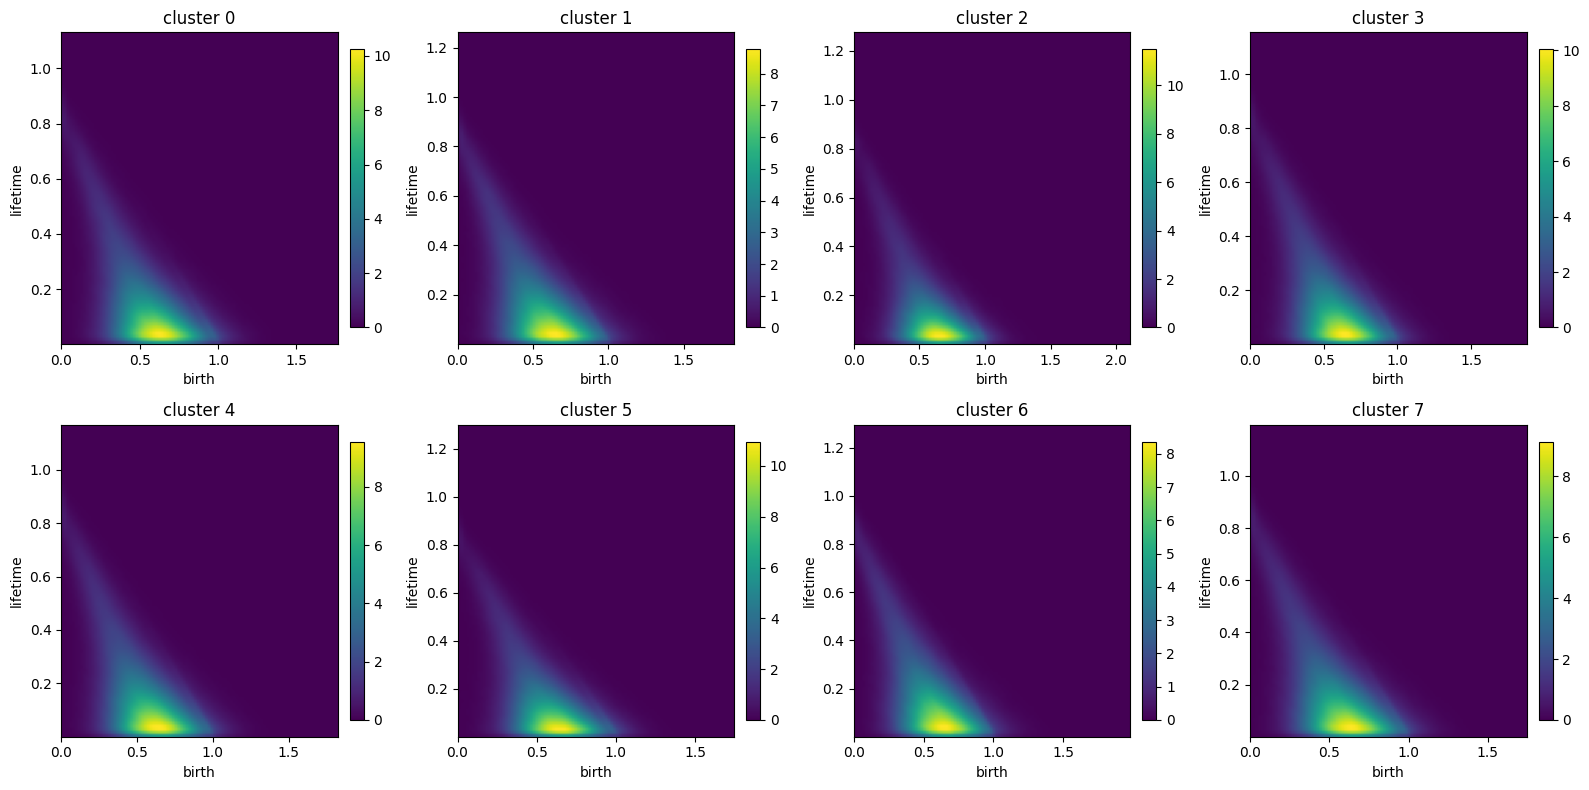

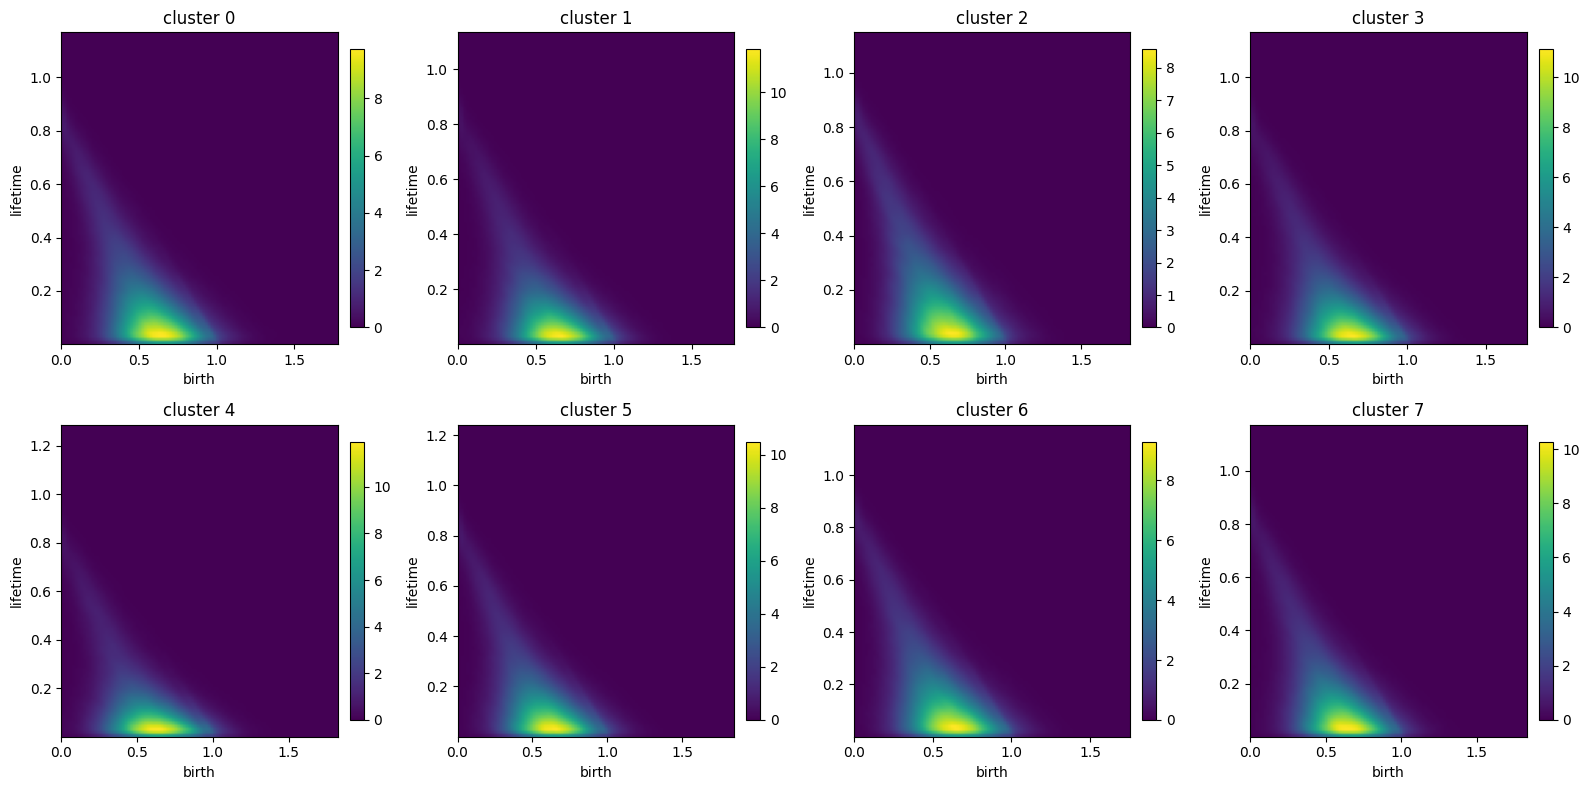

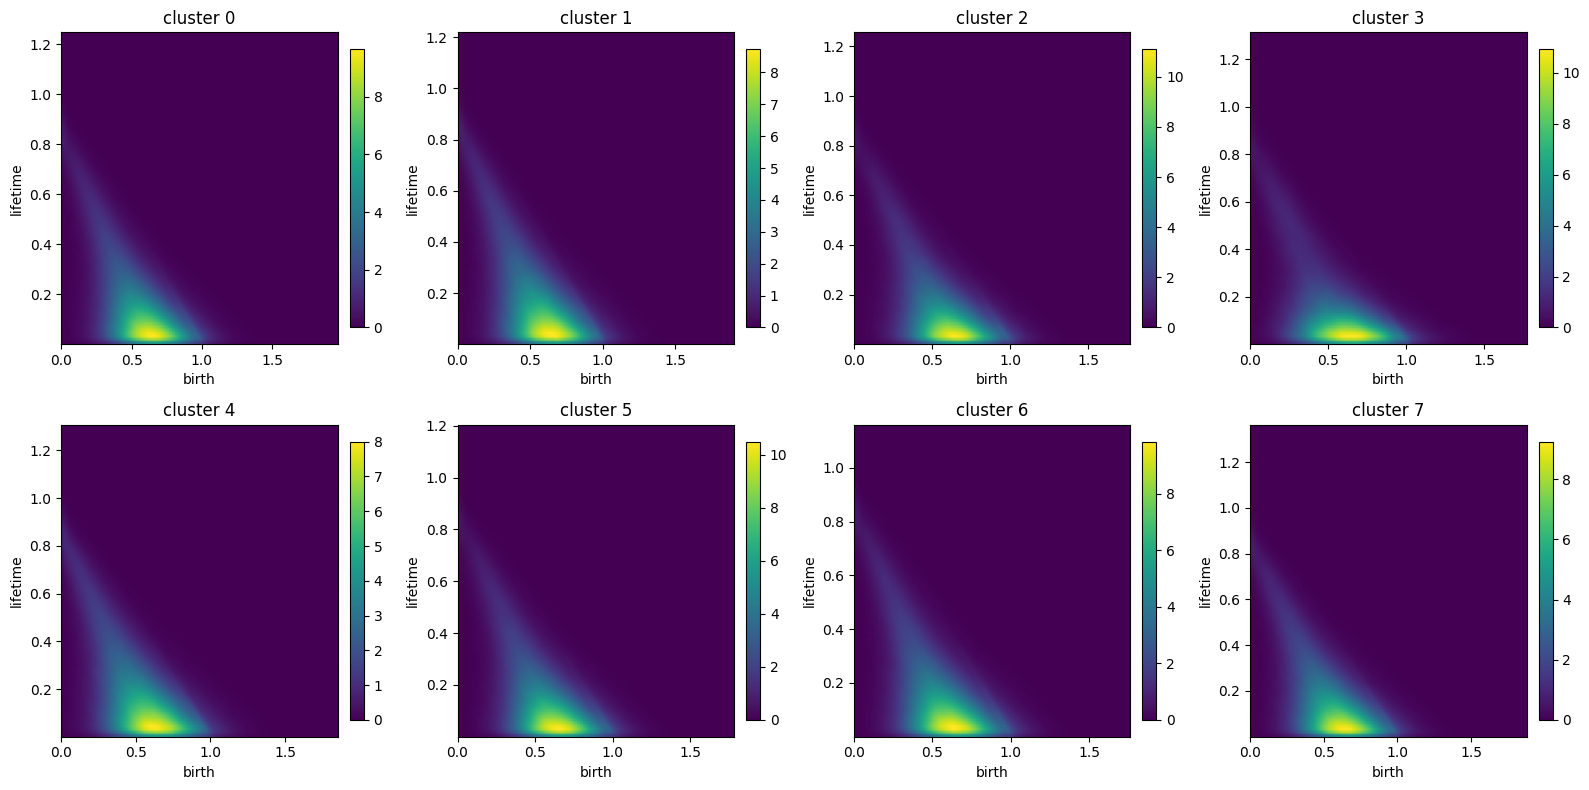

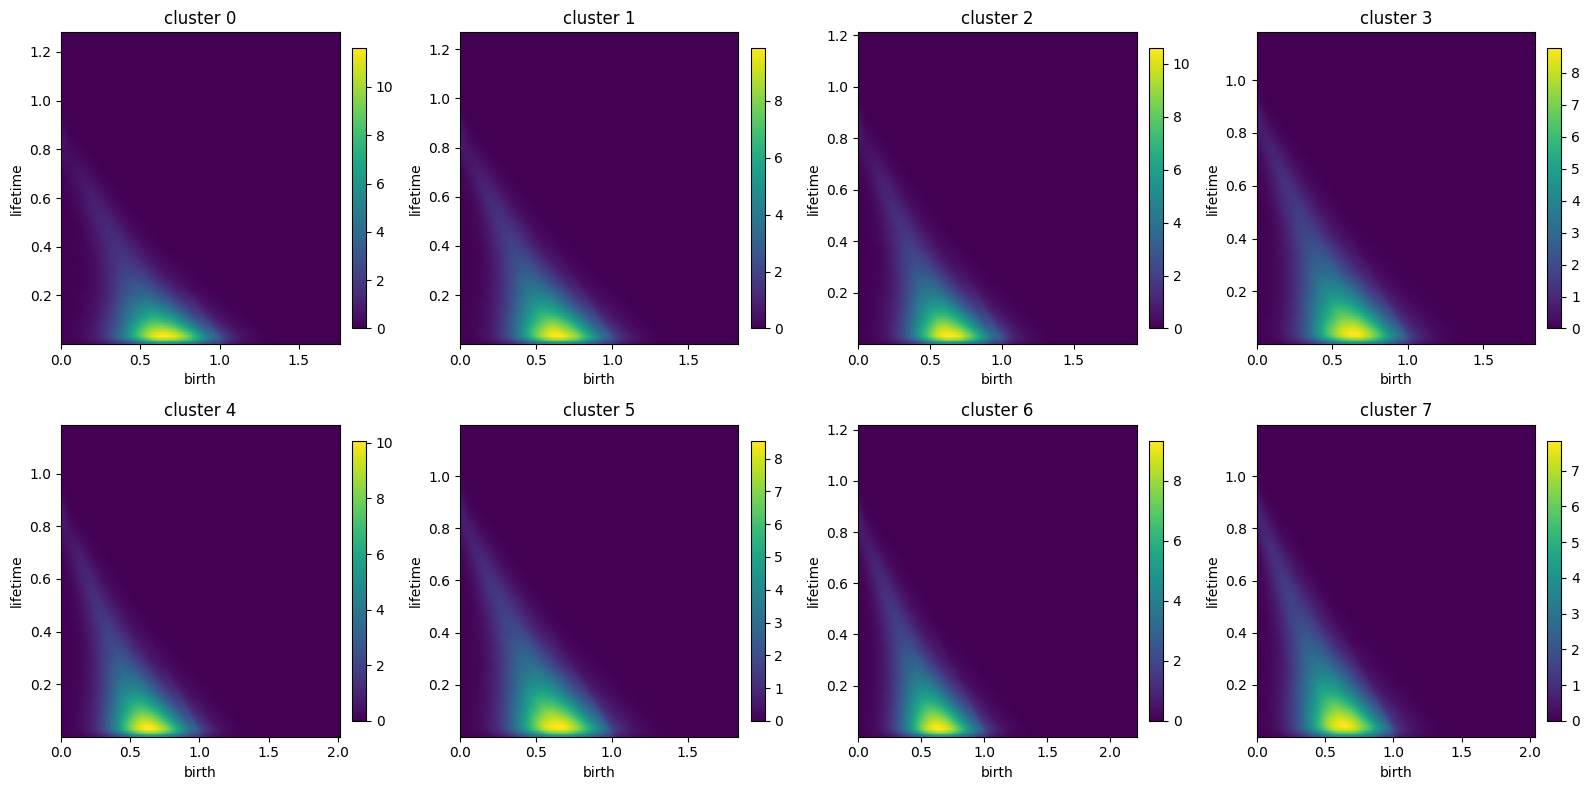

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt

for row_idx, row in df.iterrows():
    image_path = row["image"]
    densities = row["densities"]
    labels = row["clustered_labels"]
    if isinstance(densities, str):
        densities = json.loads(densities)
    cluster_densities = {}

    for cluster_label, density_data in densities.items():
        density_grid = np.array(density_data["density_grid"])
        extent = density_data.get("extent")
        cluster_densities[cluster_label] = (density_grid, extent)
    n_clusters = len(cluster_densities)
    n_cols = 4
    n_rows = int(np.ceil(n_clusters / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (label, (density_grid, extent)) in zip(axes, cluster_densities.items()):
        im = ax.imshow(density_grid, origin='lower', extent=extent, aspect='auto', cmap='viridis')
        ax.set_title(f"cluster {label}" + (" (crystalline)" if label == 4 else ""))
        ax.set_xlabel("birth")
        ax.set_ylabel("lifetime")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # hide any unused subplot axes
    for ax in axes[len(cluster_densities):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


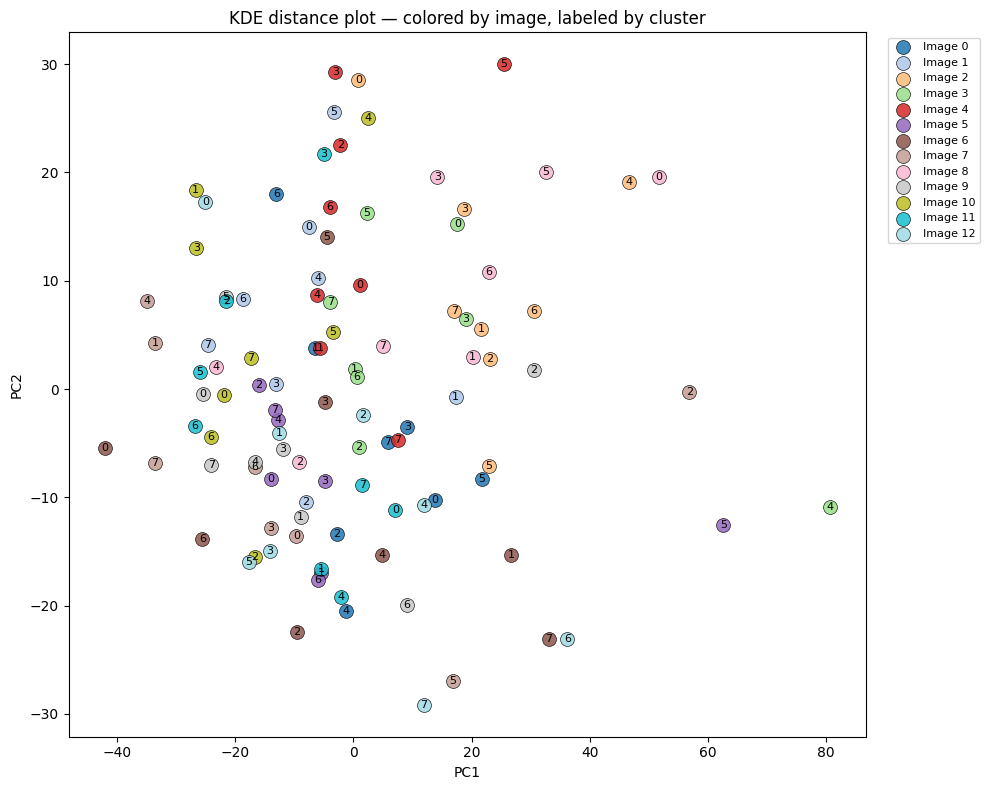

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Collect every KDE with its metadata
records = []
for row_idx, row in df.iterrows():
    densities = row["densities"]
    if isinstance(densities, str):
        densities = json.loads(densities)

    for cluster_label, density_data in densities.items():
        grid = np.array(density_data["density_grid"])
        records.append({
            "vector": grid.ravel(),
            "image_idx": row_idx,
            "cluster": cluster_label,
        })

vectors = np.stack([r["vector"] for r in records])
image_idxs = np.array([r["image_idx"] for r in records])
cluster_labels = np.array([r["cluster"] for r in records])

# 2. Project each KDE down to a single 2D point
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(vectors)

# 3. Plot — one point per KDE
n_images = df.shape[0]
cmap = plt.get_cmap("tab20", n_images)

fig, ax = plt.subplots(figsize=(10, 8))
for img_idx in range(n_images):
    mask = image_idxs == img_idx
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               color=cmap(img_idx), label=f"Image {img_idx}", s=100, alpha=0.85, edgecolors="k", linewidths=0.5)

# label each point with its cluster number
for (x, y), c in zip(coords_2d, cluster_labels):
    ax.annotate(str(c), (x, y), fontsize=8, ha="center", va="center")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("KDE distance plot — colored by image, labeled by cluster")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np
from scipy.spatial.distance import pdist, squareform

dist_matrix = squareform(pdist(vectors, metric="euclidean"))
print(dist_matrix.shape)  # (n_kdes, n_kdes)

(104, 104)


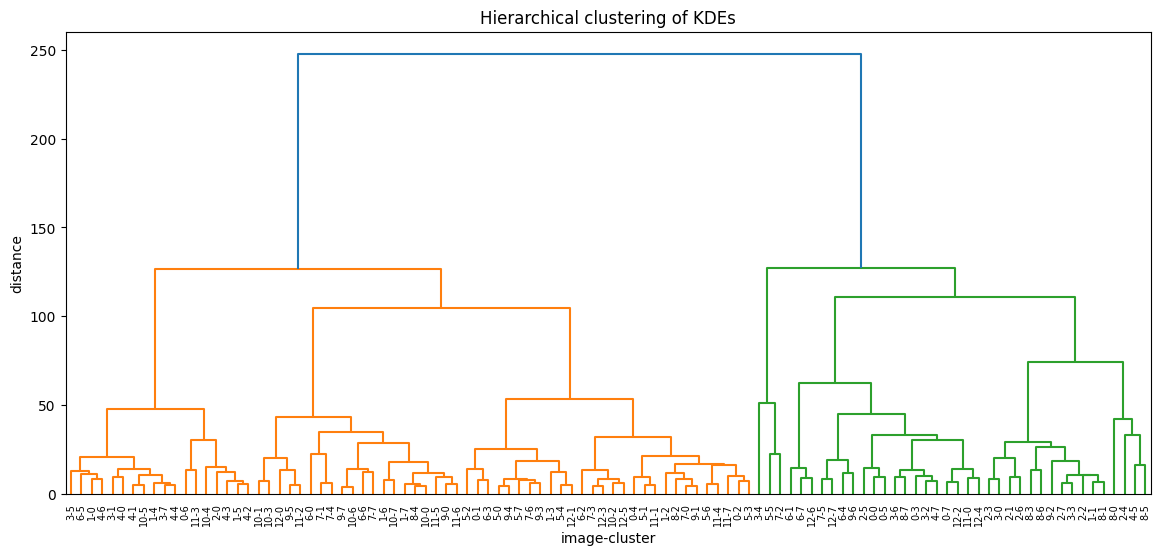

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

Z = linkage(vectors, method="ward")  # ward minimizes within-cluster variance, good default

plt.figure(figsize=(14, 6))
dendrogram(Z, labels=[f"{img}-{c}" for img, c in zip(image_idxs, cluster_labels)], leaf_font_size=7)
plt.title("Hierarchical clustering of KDEs")
plt.xlabel("image-cluster")
plt.ylabel("distance")
plt.show()

In [6]:
distance_threshold = 100  # pick based on where the dendrogram shows a natural gap
flat_groups = fcluster(Z, t=distance_threshold, criterion="distance")
print(f"Number of groups found: {len(np.unique(flat_groups))}")

Number of groups found: 6


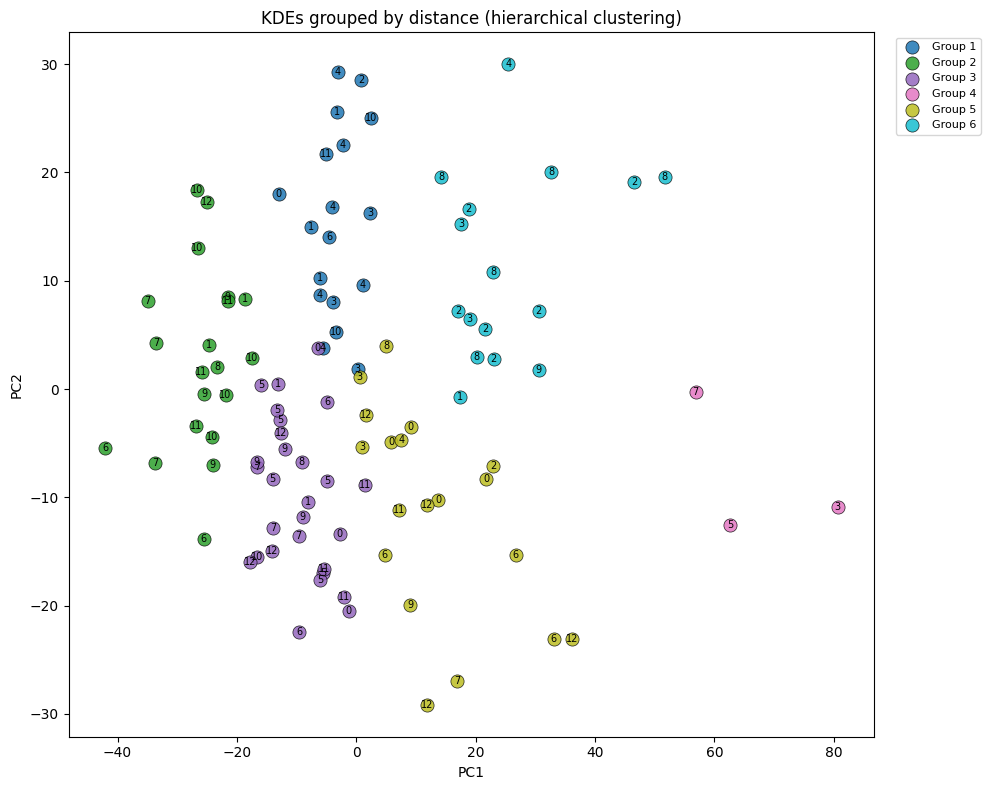

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap("tab10", len(np.unique(flat_groups)))

for group in np.unique(flat_groups):
    mask = flat_groups == group
    ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
               color=cmap(group - 1), s=90, alpha=0.85, edgecolors="k", linewidths=0.5,
               label=f"Group {group}")

for (x, y), img in zip(coords_2d, image_idxs):
    ax.annotate(str(img), (x, y), fontsize=7, ha="center", va="center")

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("KDEs grouped by distance (hierarchical clustering)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
from collections import defaultdict

pooled_by_group = defaultdict(list)

for record, group in zip(records, flat_groups):
    # reconstruct the original density_grid shape (not the flattened vector)
    grid_shape = density_grid.shape  # grab this from any original grid before flattening, e.g. np.array(density_data["density_grid"]).shape
    grid = record["vector"].reshape(grid_shape)
    pooled_by_group[group].append(grid)

group_avg_kde = {
    group: np.mean(np.stack(grids), axis=0)
    for group, grids in pooled_by_group.items()
}

In [10]:
from scipy.spatial.distance import cdist

group_medoid_idx = {}
for group in np.unique(flat_groups):
    idx = np.where(flat_groups == group)[0]
    group_vecs = vectors[idx]
    centroid = group_vecs.mean(axis=0)
    dists = cdist(group_vecs, centroid.reshape(1, -1)).ravel()
    group_medoid_idx[group] = idx[np.argmin(dists)]

group_medoid_kde = {
    group: vectors[idx].reshape(grid_shape)
    for group, idx in group_medoid_idx.items()
}

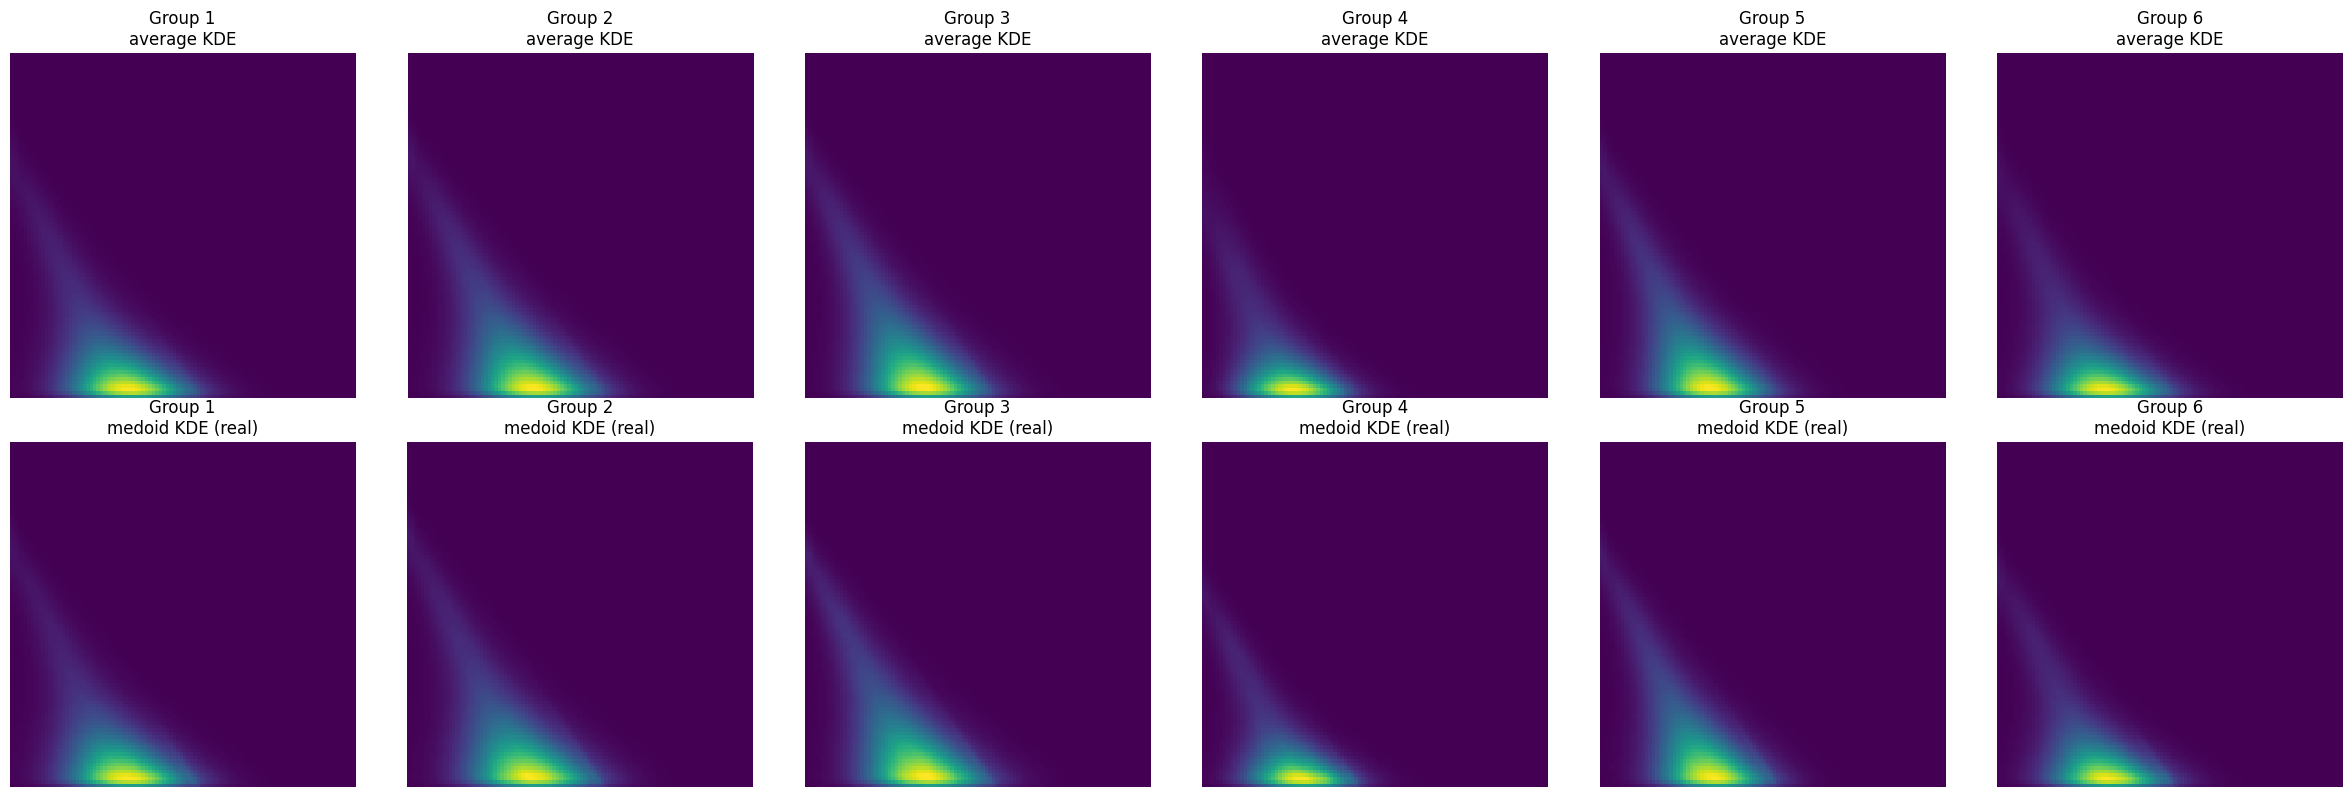

In [11]:
groups_sorted = sorted(group_avg_kde.keys())
n = len(groups_sorted)

fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
for col, group in enumerate(groups_sorted):
    axes[0, col].imshow(group_avg_kde[group], origin="lower", cmap="viridis")
    axes[0, col].set_title(f"Group {group}\naverage KDE")
    axes[0, col].axis("off")

    axes[1, col].imshow(group_medoid_kde[group], origin="lower", cmap="viridis")
    axes[1, col].set_title(f"Group {group}\nmedoid KDE (real)")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

In [7]:
import os
import tifffile  # or PIL, depending on file format — let me know once I see the folder

def resolve_image_path(df_path, old_prefix="/data/test_images", new_prefix="../hrtem_files"):
    return df_path.replace(old_prefix, new_prefix)

# quick sanity check before running the full pipeline
for img_path in df["image"]:
    resolved = resolve_image_path(img_path)
    exists = os.path.exists(resolved)
    print(f"{'OK ' if exists else 'MISSING'}  {resolved}")

OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_08.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_05.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_07.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_03.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_02.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_10.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_13.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_12.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2650e_0p1596s_14.dm3
OK   ../hrtem_files/2022_02_02 5nm Ag nanoparticles on UTC/20220202_Ag_UTC_330kx_2

In [8]:
from skimage.util import view_as_windows

def split_patches_and_positions(image, patch_size, stride):
    blocks = view_as_windows(image, window_shape=(patch_size, patch_size), step=stride)
    n_rows, n_cols = blocks.shape[:2]
    patches = blocks.reshape(-1, patch_size, patch_size)
    positions = [(i * stride, j * stride) for i in range(n_rows) for j in range(n_cols)]
    return patches, positions

In [9]:
from ncempy.io import dm
from pathlib import Path
def load_and_patch_image(img_path, patch_size=64, stride=16):
    file = Path(resolve_image_path(img_path))
    data_dict = dm.dmReader(str(file.resolve()))
    img = data_dict['data']
    patches, positions = split_patches_and_positions(img, patch_size, stride)  # from earlier
    return img, patches, positions

# build patches for every image up front, keyed by row index
all_image_patches = {}
for row_idx, row in df.iterrows():
    img, patches, positions = load_and_patch_image(row["image"])
    all_image_patches[row_idx] = {"img": img, "patches": patches, "positions": positions}

In [ ]:
from collections import defaultdict

group_patches = defaultdict(list)

for record, group in zip(records, flat_groups):
    img_idx = record["image_idx"]
    orig_cluster = record["cluster"]

    row = df.iloc[img_idx]
    row_labels = np.array(row["clustered_labels"])
    patches = all_image_patches[img_idx]["patches"]

    patch_mask = row_labels == int(orig_cluster)
    matching_patches = patches[patch_mask]
    group_patches[group].extend(matching_patches)

In [ ]:
def compute_fft_magnitude(patch, window=True):
    if window:
        wy = np.hanning(patch.shape[0])
        wx = np.hanning(patch.shape[1])
        patch = patch * np.outer(wy, wx)
    f = np.fft.fftshift(np.fft.fft2(patch))
    return np.log(np.abs(f) + 1)

group_avg_fft = {}
for group, patches in group_patches.items():
    ffts = np.array([compute_fft_magnitude(p) for p in patches])
    group_avg_fft[group] = ffts.mean(axis=0)

In [ ]:
groups_sorted = sorted(group_avg_fft.keys())
n = len(groups_sorted)

fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
for ax, group in zip(axes, groups_sorted):
    ax.imshow(group_avg_fft[group], cmap="inferno")
    ax.set_title(f"Group {group}")
    ax.axis("off")
plt.suptitle("Average FFT per distance-based group")
plt.tight_layout()
plt.show()